## Bayesian Learning and Decision-Making Under Uncertainty

#### Implications for the Description-Experience Gap

#### Introduction: 

Risky decisions are taken on an everyday basis. Examples include investment decisions, buying insurance, buying lottery tickets, what major to pursue in college, what career path to choose, and so on. Many of these cases involve learning from experience rather than description. This is because probabilities and outcomes are not explicitly known, but can be inferred from enough exploration.

A mathematical framework that studies decision making in experience scenarios is called the multi-armed bandit problem. In this setting the decision maker sequentially chooses one of multiple choices where the properties of each choice are only partially known at the time of the choice, and may become better understood through more trials (Wikipedia contributors, 2026).    

In this project we will focus on choices between two alternatives- a safe one that yields a medium outcome with certainty and a risky one that yields different outcomes with different probabilities. The decision maker will  repeatedly choose between these two options and observe the outcomes. He gradually learns about the payoff structure of the options and can make more informative subsequent decisions to increase his payoff. We use a Bayesian updating as a theoretical model of learning to see how a rational agent chooses and updates information from realized outcomes to maximize profit. In addition, we will implement simulation methods in Python that employ different learning and decision strategies to understand how beliefs evolve over time and how they influence choice behavior.    

#### Mathematical Model 

##### Multi-Armed Bandit

The name 'multi-armed bandit' originates from slot machines in casinos, where each machine represents an “arm” that produces rewards with some probability distribution. A decision maker repeatedly chooses which arm to pull and receives rewards that depend on the selected arm. 

Formally, consider a set of $K$ available actions (or arms): $A = {1,2,...,K}$. Each arm $i$ is associated with an unknown reward distribution with expected value $\mu_i = E[R_i]$ where $R_i$ denotes the reward obtained when arm $i$ is chosen.

At each time period $t = 1,2,...,T$, the decision maker selects an arm $a_t \in A$.

The goal of the decision maker is to maximize the total payoffs: $\max \sum_{t=1}^{T} R_t$


The decision maker has to find a strategy that balances between exploration and exploitation. On the one hand, exploring different arms provides information about their payoff distributions. On the other hand, exploiting the arm that currently appears to yield the highest payoff increases immediate payoffs.

##### Two-Armed Case (our setting)

In this project we will focus on a special case of the multi-armed bandit problem, where there are only two options ($K=2$). The action set is then: $A = \{S, R\}$ where $S$ denotes the safe option and $R$ denotes the risky option. At each time period $t = 1,2,\dots,T$, the decision maker chooses an action $a_t \in \{S,R\}$ and observes a realized payoff $R_t$:


$$
R_t =
\begin{cases}
c, & \text{if } a_t = S,\\
X_t, & \text{if } a_t = R,
\end{cases}
$$

where $c > 0$ is a fixed payoff and $X_t$ is a stochastic payoff, taking on the following form: 

$$
X_t =
\begin{cases}
r, & \text{with probability } p,\\
0, & \text{with probability } 1-p.
\end{cases}
$$

where $r$ is a high outcome ($r > c$) and the probability of success $p$ is unknown to the decision maker.

##### Bayesian Learning

The decision maker does not know the payoff distributions of either option in advance. The probabilities and outcomes of both the safe and the risky option must be learned from experience through repeated observations of realized outcomes. To model this learning process, we assume that the payoffs from each option follow a Bernoulli distribution with an unknown probability of success. Let $p_S$ denote the probability of success of the safe option and $p_R$ denote the probability of success of the risky option.

The decision maker begins with prior beliefs about these probabilities. A convenient prior distribution for probabilities is the Beta distribution:

$$
p_S \sim \text{Beta}(\alpha_S,\beta_S)
$$

$$
p_R \sim \text{Beta}(\alpha_R,\beta_R)
$$

where the parameters $\alpha$ and $\beta$ represent prior beliefs about the likelihood of success and failure.

After observing the safe option $n_S$ times, the decision maker has observed only successes. Then, his or her posterior belief about the success probability of the safe option becomes:

$$
p_S \mid \text{data} \sim \text{Beta}(\alpha_S + n_S,\; \beta_S).
$$

Similarly, if the risky option has been chosen $n_R$ times and yielded $s_R$ successes and $f_R$ failures, the posterior belief about its success probability is:

$$
p_R \mid \text{data} \sim \text{Beta}(\alpha_R + s_R,\; \beta_R + f_R).
$$

As the number of observations increases, the posterior distributions become more concentrated around the true probabilities of success. These updated beliefs influence the decision maker’s subsequent choices between the two options.

##### Decision Strategies

(Thompson 1933 or Sutton & Barto 2018)

Once the decision maker updates beliefs about the success probabilities of the two options, the next step is to determine how these beliefs influence the choice of option. Different decision strategies balance exploration and exploitation in different ways.

\paragraph{Greedy strategy}

A simple strategy is to always choose the option with the highest estimated expected payoff. If the decision maker's current belief about the probability of success of option $i$ is $E[p_i]$, the expected payoff of that option is

$$
E[R_i] = r_i E[p_i].
$$

The greedy strategy chooses the arm with the highest estimated expected payoff.

This strategy, however, may lead to insufficient exploration, since the decision maker may focus on one option without sufficiently exploring the alternative option.

\paragraph{Random exploration}

Another simple approach is to choose options randomly with some probability. This strategy ensures that both options are sampled over time, allowing the decision maker to gather more information about their payoff distributions.

\paragraph{Thompson Sampling}

A more sophisticated approach is Thompson Sampling, a Bayesian decision rule. Under this strategy, the decision maker draws a random value from the posterior distribution of each option:

$$
\tilde{p}_S \sim \text{Beta}(\alpha_S,\beta_S)
$$

$$
\tilde{p}_R \sim \text{Beta}(\alpha_R,\beta_R)
$$

The option with the higher drawn value is then chosen. An update on the posterior beliefs then follows. This method naturally balances exploration and exploitation.

#### Simulation Setup 

To study how different decision strategies perform in the our binary choice environment, we conduct a series of simulations in Python.

In the simulated environment, the decision maker repeatedly chooses between a safe option and a risky option over a finite time horizon $T$. The safe option yields a constant payoff $c$, while the risky option yields a payoff $r$ with probability $p$ and zero otherwise.

The decision maker does not know the payoff distributions of the options initially. Instead, the probabilities of success are learned through experience using Bayesian updating.

Prior beliefs in the beginning are given by Beta distributions:

$$
p_S \sim \text{Beta}(\alpha_S,\beta_S)
$$

$$
p_R \sim \text{Beta}(\alpha_R,\beta_R)
$$

We simulate a sequence of choices over $T$ periods. After each choice, the realized payoff is observed and the corresponding posterior distribution is updated.

The performance of the different decision strategies is evaluated by comparing the cumulative payoffs obtained over time.

#### Python Implementation

In [43]:
# Import libraries for numerical computation and plotting
import numpy as np
import matplotlib.pyplot as plt

In [44]:
# Define parameters of the environment

T = 1000          # number of decision periods
c = 3            # payoff of the safe option
r = 4            # payoff of the risky option
p = 0.8          # probability of success of the risky option

In [45]:
# Initial parameters of the Beta priors

alpha_S = 1
beta_S = 1

alpha_R = 1
beta_R = 1

In [46]:
# Lists to store results

rewards = []
choices = []

In [47]:
# Thompson Simulation

for t in range(T):

    # Sample probabilities from the posterior distributions
    pS_sample = np.random.beta(alpha_S, beta_S)
    pR_sample = np.random.beta(alpha_R, beta_R)

    # Compute sampled expected payoffs
    value_S = c * pS_sample
    value_R = r * pR_sample

    # Choose the option with the higher sampled value
    if value_R > value_S:
        choice = "R"
    else:
        choice = "S"

    choices.append(choice)

    # Generate outcome from the environment
    if choice == "S":
        reward = c
        success = 1

        alpha_S += 1

    else:
        success = np.random.rand() < p
        reward = r * success

        if success:
            alpha_R += 1
        else:
            beta_R += 1

    rewards.append(reward)

In [48]:
# Calculate cumulative reward

cumulative_rewards = np.cumsum(rewards)

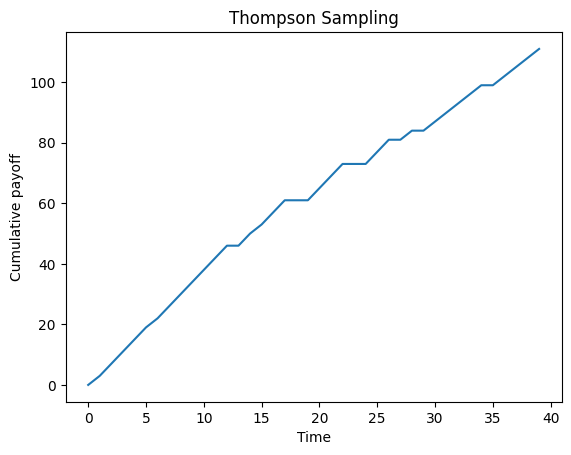

In [38]:
# Plot cumulative rewards

plt.plot(cumulative_rewards)
plt.xlabel("Time")
plt.ylabel("Cumulative payoff")
plt.title("Thompson Sampling")
plt.show()

In [53]:
# Count how many times each option was chosen

safe_count = choices.count("S")
risky_count = choices.count("R")

print("Safe option chosen:", safe_count)
print("Risky option chosen:", risky_count)

Safe option chosen: 65
Risky option chosen: 935


In [49]:
# Greedy strategy simulation

alpha_S = 1
beta_S = 1
alpha_R = 1
beta_R = 1

choices_greedy = []
rewards_greedy = []

for t in range(T):

    # compute expected probabilities
    pS_est = alpha_S / (alpha_S + beta_S)
    pR_est = alpha_R / (alpha_R + beta_R)

    # compute expected payoffs
    value_S = c * pS_est
    value_R = r * pR_est

    # choose option with higher expected payoff
    if value_R > value_S:
        choice = "R"
    else:
        choice = "S"

    choices_greedy.append(choice)

    # generate outcome
    if choice == "S":
        reward = c
        success = 1
        alpha_S += 1

    else:
        success = np.random.rand() < p
        reward = r * success

        if success:
            alpha_R += 1
        else:
            beta_R += 1

    rewards_greedy.append(reward)

cum_greedy = np.cumsum(rewards_greedy)

In [50]:
# Random exploration simulation

alpha_S = 1
beta_S = 1
alpha_R = 1
beta_R = 1

choices_random = []
rewards_random = []

for t in range(T):

    # choose randomly
    if np.random.rand() < 0.5:
        choice = "S"
    else:
        choice = "R"

    choices_random.append(choice)

    # generate outcome
    if choice == "S":
        reward = c
        success = 1
        alpha_S += 1

    else:
        success = np.random.rand() < p
        reward = r * success

        if success:
            alpha_R += 1
        else:
            beta_R += 1

    rewards_random.append(reward)

cum_random = np.cumsum(rewards_random)

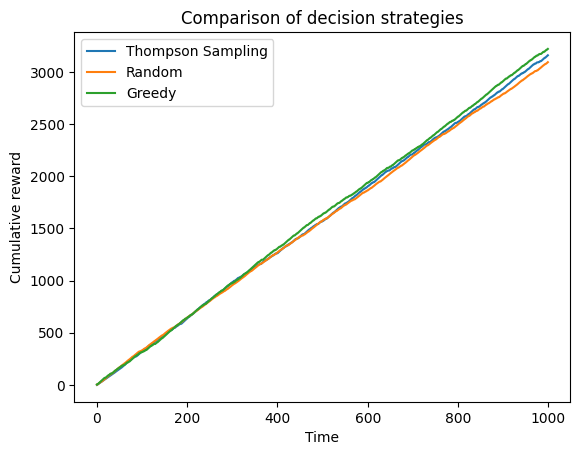

In [51]:
plt.plot(cumulative_rewards, label="Thompson Sampling")
plt.plot(cum_random, label="Random")
plt.plot(cum_greedy, label="Greedy")

plt.xlabel("Time")
plt.ylabel("Cumulative reward")
plt.title("Comparison of decision strategies")
plt.legend()
plt.show()

In [54]:
print("Random:  S =", choices_random.count("S"), " R =", choices_random.count("R"))
print("Greedy:  S =", choices_greedy.count("S"), " R =", choices_greedy.count("R"))
print("Thompson:S =", choices.count("S"), " R =", choices.count("R"))

Random:  S = 519  R = 481
Greedy:  S = 0  R = 1000
Thompson:S = 65  R = 935


#### Results and Discussion

## Bibliography: 

Wikipedia contributors. (2026). Multi-armed bandit. Wikipedia.
https://en.wikipedia.org/wiki/Multi-armed_bandit

